# Plot: TDA vs Network Baselines

This notebook creates a rebuttal-ready figure comparing TDA with simpler network-based indicators computed from the same distance matrices.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BASE_DIR = Path('/Users/jane/Documents/202511吾-Systems/8. New data/network_based_vs_tda')
OUTPUT_DIR = Path('/Users/jane/Documents/202511吾-Systems/10. New Plot')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_WINDOW_PATH = BASE_DIR / 'cmc15_tda_vs_network_best_by_window.csv'
PAIRWISE_GROUP_PATH = BASE_DIR / 'cmc15_tda_vs_network_pairwise_group_summary.csv'
CORR_SUMMARY_PATH = BASE_DIR / 'cmc15_tda_network_correlation_summary.csv'

WINDOW_ORDER = ['[-21,0]', '[-14,0]', '[-7,0]', '[0,+7]', '[0,+21]']
METHOD_ORDER = ['dtw', 'euclidean', 'wasserstein']
METHOD_LABELS = {'dtw': 'DTW', 'euclidean': 'Euclidean', 'wasserstein': 'Wasserstein'}
COLORS = {
    'tda': '#1f5aa6',
    'network': '#d97746',
    'dtw': '#1f5aa6',
    'euclidean': '#2a9d8f',
    'wasserstein': '#c44e52',
    'predictive_bg': '#eaf4fb',
    'reactive_bg': '#fdf1e6',
}

print('Reading:', BEST_WINDOW_PATH)
print('Reading:', PAIRWISE_GROUP_PATH)


Reading: /Users/jane/Documents/202511吾-Systems/8. New data/network_based_vs_tda/cmc15_tda_vs_network_best_by_window.csv
Reading: /Users/jane/Documents/202511吾-Systems/8. New data/network_based_vs_tda/cmc15_tda_vs_network_pairwise_group_summary.csv


In [2]:
best_window = pd.read_csv(BEST_WINDOW_PATH)
pairwise_group = pd.read_csv(PAIRWISE_GROUP_PATH)
corr_summary = pd.read_csv(CORR_SUMMARY_PATH)

plot_window = best_window[['window_label', 'auc_tda', 'auc_network', 'tda_minus_network_auc']].copy()
plot_window = plot_window.set_index('window_label').loc[WINDOW_ORDER].reset_index()
plot_window['window_type'] = np.where(plot_window['window_label'].isin(['[-21,0]', '[-14,0]', '[-7,0]']), 'Predictive', 'Contemporaneous/Lagged')

plot_method = pairwise_group.copy()
plot_method['method_label'] = plot_method['distance_method'].map(METHOD_LABELS)
plot_method = plot_method.set_index('distance_method').loc[METHOD_ORDER].reset_index()

top_corr = corr_summary.iloc[0]
low_corr = corr_summary[(corr_summary['tda_feature'] == 'persistent_entropy') & (corr_summary['network_feature'] == 'pagerank_max')].iloc[0]

tbl_window = plot_window.rename(columns={
    'window_label': 'Evaluation Window',
    'window_type': 'Window Type',
    'auc_tda': 'Best TDA AUC',
    'auc_network': 'Best Network AUC',
    'tda_minus_network_auc': 'TDA - Network AUC Gap',
})
tbl_method = plot_method.rename(columns={
    'method_label': 'Distance Method',
    'n_specifications': 'Matched Specifications',
    'tda_win_count': 'TDA Wins',
    'network_win_count': 'Network Wins',
    'mean_tda_minus_network_auc': 'Mean TDA - Network AUC',
    'median_tda_minus_network_auc': 'Median TDA - Network AUC',
    'max_tda_minus_network_auc': 'Max TDA - Network AUC',
    'min_tda_minus_network_auc': 'Min TDA - Network AUC',
})

tbl_window.to_csv(OUTPUT_DIR / 'tbl_tda_vs_network_best_by_window.csv', index=False)
tbl_method.to_csv(OUTPUT_DIR / 'tbl_tda_vs_network_by_method.csv', index=False)

display(tbl_window)
display(tbl_method)


,Evaluation Window,Best TDA AUC,Best Network AUC,TDA - Network AUC Gap,Window Type
0,"[-21,0]",0.664299,0.646626,0.017673,Predictive
1,"[-14,0]",0.636218,0.618942,0.017275,Predictive
2,"[-7,0]",0.649221,0.634009,0.015212,Predictive
3,"[0,+7]",0.649443,0.635526,0.013917,Contemporaneous/Lagged
4,"[0,+21]",0.688595,0.677268,0.011326,Contemporaneous/Lagged


,distance_method,Matched Specifications,TDA Wins,Network Wins,Mean TDA - Network AUC,Median TDA - Network AUC,Max TDA - Network AUC,Min TDA - Network AUC,Distance Method
0,dtw,12,12,0,0.028593,0.030512,0.040856,0.017461,DTW
1,euclidean,12,12,0,0.021030,0.023161,0.030176,0.001674,Euclidean
2,wasserstein,12,12,0,0.015089,0.015526,0.021085,0.006166,Wasserstein


/var/folders/np/ry82r7v95y33d2df6jpjnr4c0000gn/T/ipykernel_75385/2730726483.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.05, 1, 0.97])


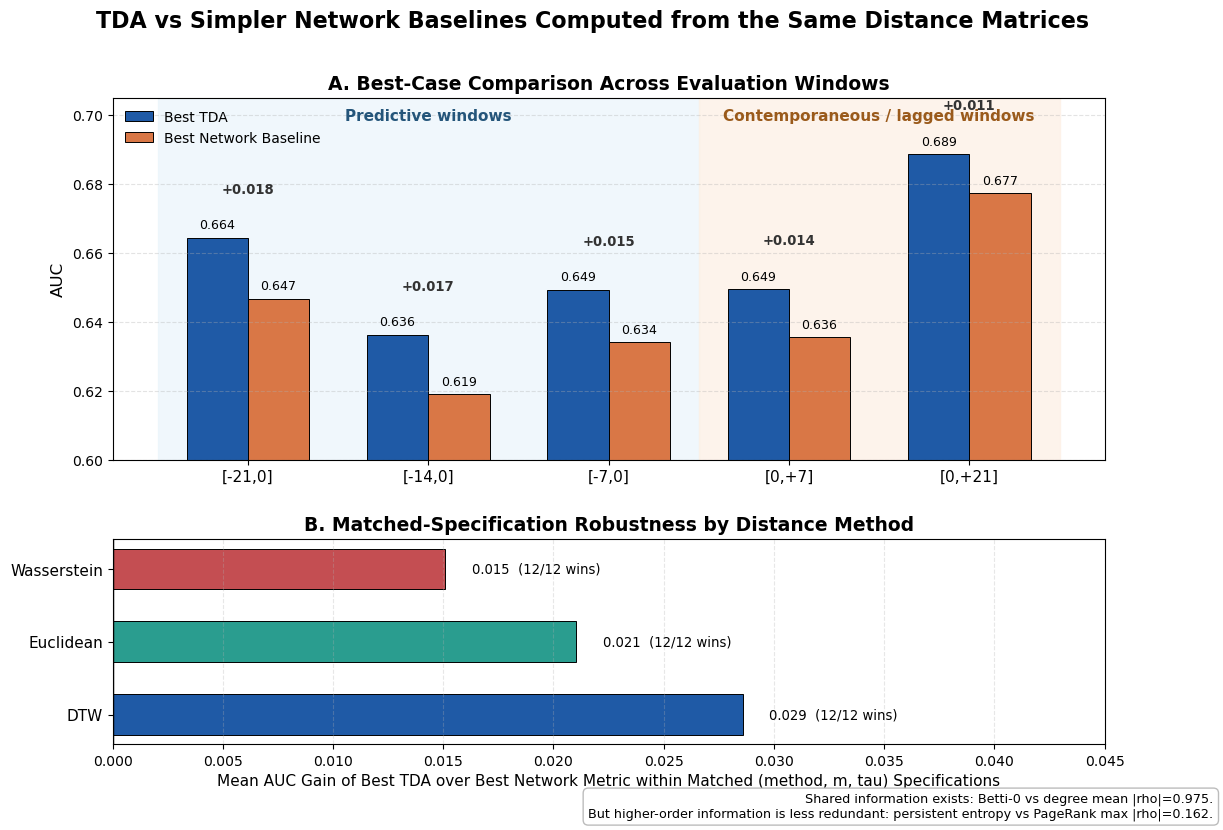

In [3]:
x = np.arange(len(plot_window))
bar_width = 0.34

fig = plt.figure(figsize=(12.8, 8.4))
gs = fig.add_gridspec(2, 1, height_ratios=[3.0, 1.7], hspace=0.28)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.axvspan(-0.5, 2.5, color=COLORS['predictive_bg'], alpha=0.70, zorder=0)
ax1.axvspan(2.5, 4.5, color=COLORS['reactive_bg'], alpha=0.80, zorder=0)

bars_tda = ax1.bar(x - bar_width/2, plot_window['auc_tda'], width=bar_width, color=COLORS['tda'], edgecolor='black', linewidth=0.7, label='Best TDA')
bars_net = ax1.bar(x + bar_width/2, plot_window['auc_network'], width=bar_width, color=COLORS['network'], edgecolor='black', linewidth=0.7, label='Best Network Baseline')

for bar in list(bars_tda) + list(bars_net):
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.0018, f'{h:.3f}', ha='center', va='bottom', fontsize=9)

for i, row in plot_window.iterrows():
    top = max(row['auc_tda'], row['auc_network'])
    ax1.text(i, top + 0.012, f"+{row['tda_minus_network_auc']:.3f}", ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#333333')

ax1.set_xticks(x)
ax1.set_xticklabels(plot_window['window_label'], fontsize=11)
ax1.set_ylabel('AUC', fontsize=12)
ax1.set_ylim(0.60, 0.705)
ax1.set_title('A. Best-Case Comparison Across Evaluation Windows', fontsize=13.5, fontweight='bold')
ax1.yaxis.grid(True, linestyle='--', alpha=0.35)
ax1.legend(frameon=False, loc='upper left', fontsize=10)
ax1.text(1.0, 0.702, 'Predictive windows', ha='center', va='top', fontsize=11, fontweight='bold', color='#24557a')
ax1.text(3.5, 0.702, 'Contemporaneous / lagged windows', ha='center', va='top', fontsize=11, fontweight='bold', color='#9a5a1b')

y = np.arange(len(plot_method))
bars = ax2.barh(y, plot_method['mean_tda_minus_network_auc'], color=[COLORS[m] for m in plot_method['distance_method']], edgecolor='black', linewidth=0.7, height=0.56)
ax2.axvline(0, color='black', linewidth=1)

for yi, row in zip(y, plot_method.itertuples(index=False)):
    ax2.text(row.mean_tda_minus_network_auc + 0.0012, yi, f"{row.mean_tda_minus_network_auc:.3f}  ({int(row.tda_win_count)}/{int(row.n_specifications)} wins)", va='center', fontsize=9.5)

ax2.set_yticks(y)
ax2.set_yticklabels(plot_method['method_label'], fontsize=11)
ax2.set_xlabel('Mean AUC Gain of Best TDA over Best Network Metric within Matched (method, m, tau) Specifications', fontsize=11)
ax2.set_title('B. Matched-Specification Robustness by Distance Method', fontsize=13.5, fontweight='bold')
ax2.xaxis.grid(True, linestyle='--', alpha=0.30)
ax2.set_xlim(0, max(0.045, plot_method['mean_tda_minus_network_auc'].max() + 0.01))

textbox = (
    f"Shared information exists: Betti-0 vs degree mean |rho|={top_corr['mean_abs_spearman_rho']:.3f}.\n"
    f"But higher-order information is less redundant: persistent entropy vs PageRank max |rho|={abs(low_corr['mean_spearman_rho']):.3f}."
)
fig.text(0.985, 0.02, textbox, ha='right', va='bottom', fontsize=9.2,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#b7b7b7', alpha=0.92))

fig.suptitle('TDA vs Simpler Network Baselines Computed from the Same Distance Matrices', fontsize=16, fontweight='bold', y=0.985)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
fig.savefig(OUTPUT_DIR / 'fig_tda_vs_network_baseline.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'fig_tda_vs_network_baseline.pdf', bbox_inches='tight')
plt.show()


In [4]:
manifest = pd.DataFrame({
    'file_name': [
        'fig_tda_vs_network_baseline.png',
        'fig_tda_vs_network_baseline.pdf',
        'tbl_tda_vs_network_best_by_window.csv',
        'tbl_tda_vs_network_by_method.csv',
    ]
})
manifest['path'] = manifest['file_name'].map(lambda x: str(OUTPUT_DIR / x))
manifest.to_csv(OUTPUT_DIR / 'tda_vs_network_plot_manifest.csv', index=False)

print('Saved files:')
for name in manifest['file_name']:
    print('-', name)

display(manifest)


Saved files:
- fig_tda_vs_network_baseline.png
- fig_tda_vs_network_baseline.pdf
- tbl_tda_vs_network_best_by_window.csv
- tbl_tda_vs_network_by_method.csv


,file_name,path
0,fig_tda_vs_network_baseline.png,/Users/jane/Documents/202511吾-Systems/10. New ...
1,fig_tda_vs_network_baseline.pdf,/Users/jane/Documents/202511吾-Systems/10. New ...
2,tbl_tda_vs_network_best_by_window.csv,/Users/jane/Documents/202511吾-Systems/10. New ...
3,tbl_tda_vs_network_by_method.csv,/Users/jane/Documents/202511吾-Systems/10. New ...
